In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("retail_smart_store.csv")
df.head()

,Customer_ID,Age,Gender,City,Product_Category,Price,Quantity,Purchase_Date,Payment_Method,Discount,Rating
0,C001,22,Male,Bangalore,Electronics,15000.0,1,2025-01-12,UPI,10,4
1,C002,35,Female,Chennai,Clothing,2000.0,2,2025-01-15,Card,5,5
2,C003,29,Male,Hyderabad,Groceries,500.0,5,2025-01-16,Cash,0,3
3,C004,42,Female,Mumbai,Electronics,30000.0,1,2025-01-20,UPI,15,4
4,C005,23,Male,Bangalore,Clothing,NaN,3,2025-02-02,Card,10,5


In [ ]:
# Fix missing values
df['Price'] = df['Price'].fillna(df['Price'].mean())

# Create Total Amount
df['Total_Amount'] = df['Price'] * df['Quantity']

# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# High spender if total amount > 10000
df['High_Spender'] = (df['Total_Amount'] > 10000).astype(int)

df.head()

,Customer_ID,Age,Gender,City,Product_Category,Price,Quantity,Purchase_Date,Payment_Method,Discount,Rating,Total_Amount,High_Spender
0,C001,22,Male,Bangalore,Electronics,15000.0,1,2025-01-12,UPI,10,4,15000.0,1
1,C002,35,Female,Chennai,Clothing,2000.0,2,2025-01-15,Card,5,5,4000.0,0
2,C003,29,Male,Hyderabad,Groceries,500.0,5,2025-01-16,Cash,0,3,2500.0,0
3,C004,42,Female,Mumbai,Electronics,30000.0,1,2025-01-20,UPI,15,4,30000.0,1
4,C005,23,Male,Bangalore,Clothing,9950.0,3,2025-02-02,Card,10,5,29850.0,1


In [ ]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['City'] = le.fit_transform(df['City'])
df['Product_Category'] = le.fit_transform(df['Product_Category'])
df['Payment_Method'] = le.fit_transform(df['Payment_Method'])

In [ ]:
X = df[['Age', 'Gender', 'City', 'Product_Category', 'Price', 'Quantity', 'Discount']]
y = df['High_Spender']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


c:\THRIANX\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


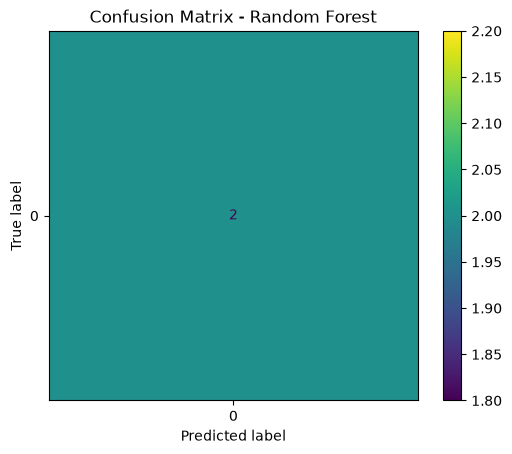

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

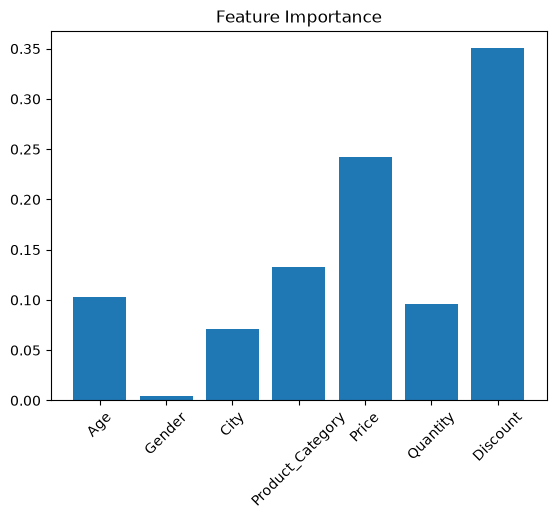

In [ ]:
importance = rf_model.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

## 🤖 Model Insights

- Random Forest performs better than Decision Tree
- Price and Quantity are most important features
- High spending behavior depends on product category and discount
- Model can be used for targeted marketing